# 🏦 Loan Prediction Model Training

**Problem Statement**: - Predict whether a loan application has possibility of repay the loan or not
**Traget Variable**: - `loan_paid_back` (1=Repayed , 0=Defaulted)

---
### Notebook Structure
1. Import related libs and configuration 
2. Load Data
3. Define Features and Target
4. Preprocessing Piepline 
5. Train/Test Spit
6. Cross Validation
7. Compare Model Results
8. Final Evaluation on Test Set
9. Save Best Model

## 1. Import related libs and configuration 

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os 

warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn - Model Selection
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold

# Models 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Sklearn - Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

# Plot Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

## 2. Load Data

In [75]:
df = pd.read_csv('../data/loan_dataset_cleaned.csv')
df.head()

,age,gender,marital_status,education_level,employment_status,debt_to_income_ratio,credit_score,loan_amount,loan_purpose,interest_rate,loan_term,num_of_open_accounts,num_of_delinquencies,loan_paid_back,annual_income_log,current_balance_log
0,59,male,married,master's,employed,0.074,743.0,17173.72,car,13.39,36,7,1,1,10.095809,10.098358
1,72,female,married,bachelor's,employed,0.219,531.0,22663.89,debt_consolidation,17.81,60,5,3,1,9.912149,9.287673
2,49,female,single,high_school,employed,0.234,779.0,3631.36,business,9.53,60,2,0,1,10.172858,8.413263
3,35,female,single,high_school,employed,0.264,809.0,14939.23,other,7.99,36,7,5,1,9.382177,8.617334
4,63,other,single,other,employed,0.260,663.0,16551.71,car,15.20,60,1,2,1,10.139644,8.187274


In [76]:
# Traget variable distribution
df.loan_paid_back.value_counts(normalize=True).round(2)*100

loan_paid_back
1    80.0
0    20.0
Name: proportion, dtype: float64

## 3. Define Features and Target

In [77]:
# Target variable
y = df['loan_paid_back']
# Features
numeric_features = [
    'age', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
    'interest_rate', 'loan_term', 'num_of_open_accounts',
    'num_of_delinquencies', 'annual_income_log', 'current_balance_log'
]

categorical_features = [
    'gender', 'marital_status', 'education_level',
    'employment_status', 'loan_purpose'
]

X = df[numeric_features + categorical_features]

print(f'Features : {X.shape[1]} ({len(numeric_features)}, {len(categorical_features)})')
print(f'samples  : {X.shape[0]:,}')

Features : 15 (10, 5)
samples  : 20,000


## 4. Preprocessing Piepline 


In [78]:
# Numeric Pipeline
numeric_transformer = Pipeline(steps = [
    ('scaler', StandardScaler())
]) 

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Define Preprocessor 
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


## 5. Train/Test Spit

In [79]:
# Train/ Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

X_train.shape , X_test.shape, y_train.shape, y_test.shape

((16000, 15), (4000, 15), (16000,), (4000,))

## 6. Cross Validation

In [80]:
# Define Models 
# Calculate imbalance ratio for XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos  # ~4.0 in your dataset

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
    'Decision Tree'       : DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced'),
    'XGBoost'             : XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=RANDOM_STATE, scale_pos_weight=scale),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5)  # KNN doesn't support class_weight
}

# Cross Validation setup

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['roc_auc', 'f1', 'precision', 'recall']
#Run CV for each model
cv_results = {}

print('Running Cross Validation...\n')
print(f'{"Model":<22} {"AUC Mean":>10} {"AUC Std":>10} {"F1 Mean":>10} {"F1 Std":>10}')
print('─' * 65)

# Cross Validation loop
for name, clf in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor',preprocessor),
        ('classifier',clf)
    ])

    scores = cross_validate(
        pipeline,
        X= X_train,
        y= y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=1
    )

    cv_results[name] = {
        'auc_mean'  : scores['test_roc_auc'].mean(),
        'auc_std'   : scores['test_roc_auc'].std(),
        'f1_mean'   : scores['test_f1'].mean(),
        'f1_std'    : scores['test_f1'].std(),
        'prec_mean' : scores['test_precision'].mean(),
        'rec_mean'  : scores['test_recall'].mean(),
        'pipeline'  : pipeline
    }

    print(f'{name:<22} {scores["test_roc_auc"].mean():>10.4f} '
          f'{scores["test_roc_auc"].std():>10.4f} '
          f'{scores["test_f1"].mean():>10.4f} '
          f'{scores["test_f1"].std():>10.4f}')


Running Cross Validation...

Model                    AUC Mean    AUC Std    F1 Mean     F1 Std
─────────────────────────────────────────────────────────────────
Logistic Regression        0.8851     0.0064     0.8722     0.0063
Decision Tree              0.7534     0.0086     0.9022     0.0045
Random Forest              0.8732     0.0057     0.9400     0.0033
XGBoost                    0.8776     0.0050     0.9087     0.0042
KNN                        0.7481     0.0099     0.9034     0.0012


## 7. Compare Model Results

In [81]:
#  Results DataFrame 
results_df = pd.DataFrame([
    {
        'Model'          : name,
        'CV AUC (mean)'  : round(v['auc_mean'],  4),
        'CV AUC (std)'   : round(v['auc_std'],   4),
        'CV F1 (mean)'   : round(v['f1_mean'],   4),
        'CV F1 (std)'    : round(v['f1_std'],    4),
        'CV Precision'   : round(v['prec_mean'], 4),
        'CV Recall'      : round(v['rec_mean'],  4),
    }
    for name, v in cv_results.items()
]).sort_values('CV AUC (mean)', ascending=False).reset_index(drop=True)

results_df.style.background_gradient(cmap='Greens', subset=['CV AUC (mean)', 'CV F1 (mean)'])

,Model,CV AUC (mean),CV AUC (std),CV F1 (mean),CV F1 (std),CV Precision,CV Recall
0,Logistic Regression,0.885100,0.006400,0.872200,0.006300,0.925600,0.824700
1,XGBoost,0.877600,0.005000,0.908700,0.004200,0.912100,0.905500
2,Random Forest,0.873200,0.005700,0.940000,0.003300,0.893200,0.991900
3,Decision Tree,0.753400,0.008600,0.902200,0.004500,0.901100,0.903300
4,KNN,0.748100,0.009900,0.903400,0.001200,0.844300,0.971400


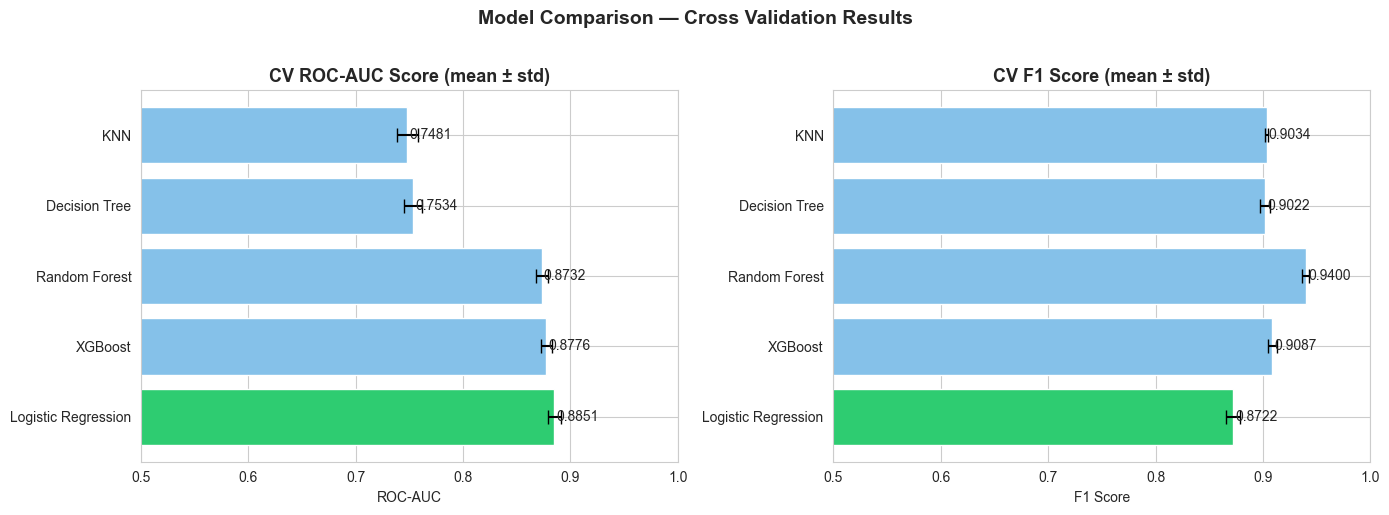


🏆 Best Model: Logistic Regression
   CV AUC : 0.8851 ± 0.0064


In [82]:
#  Visualise CV AUC Comparison 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if i == 0 else '#85c1e9' for i in range(len(results_df))]

# AUC bar chart
axes[0].barh(results_df['Model'], results_df['CV AUC (mean)'],
             xerr=results_df['CV AUC (std)'], color=colors,
             edgecolor='white', capsize=5)
axes[0].set_title('CV ROC-AUC Score (mean ± std)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_xlim(0.5, 1.0)
for i, v in enumerate(results_df['CV AUC (mean)']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

# F1 bar chart
axes[1].barh(results_df['Model'], results_df['CV F1 (mean)'],
             xerr=results_df['CV F1 (std)'], color=colors,
             edgecolor='white', capsize=5)
axes[1].set_title('CV F1 Score (mean ± std)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('F1 Score')
axes[1].set_xlim(0.5, 1.0)
for i, v in enumerate(results_df['CV F1 (mean)']):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

plt.suptitle('Model Comparison — Cross Validation Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  Pick Best Model 
best_model_name = results_df.iloc[0]['Model']
print(f'\n🏆 Best Model: {best_model_name}')
print(f'   CV AUC : {results_df.iloc[0]["CV AUC (mean)"]:.4f} ± {results_df.iloc[0]["CV AUC (std)"]:.4f}')

In [83]:
from sklearn.model_selection import RandomizedSearchCV

# Param grids per model type
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['lbfgs', 'saga']
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10]
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__subsample': [0.7, 0.8, 1.0]
    },
    'Decision Tree': {
        'classifier__max_depth': [3, 5, 10, None],
        'classifier__min_samples_split': [2, 5, 10]
    },
    'KNN': {
        'classifier__n_neighbors': [3, 5, 7, 11, 15],
        'classifier__weights': ['uniform', 'distance']
    }
}

print(f'Tuning best model: {best_model_name}...')

best_pipeline_unfit = cv_results[best_model_name]['pipeline']  # unfitted pipeline

search = RandomizedSearchCV(
    best_pipeline_unfit,
    param_distributions=param_grids[best_model_name],
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f'\nBest params : {search.best_params_}')
print(f'Best CV AUC : {search.best_score_:.4f}')

tuned_pipeline = search.best_estimator_

Tuning best model: Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best params : {'classifier__solver': 'saga', 'classifier__C': 1}
Best CV AUC : 0.8851


## 8. Final Evaluation on Test Set

In [84]:
# Best Model in Cross Validation
best_pipeline = cv_results[best_model_name]['pipeline']
best_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'debt_to_income_ratio',
                                                   'credit_score',
                                                   'loan_amount',
                                                   'interest_rate', 'loan_term',
                                                   'num_of_open_accounts',
                                                   'num_of_delinquencies',
                                                   'annual_income_log',
                                                   'current_balance_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'marital_status',
                                                   'education_level',
                                                   'employment_status',
                                                   'loan_purpose'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [85]:
# Prediction
y_pred = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Metrics 
auc = roc_auc_score(y_test, y_pred_proba)

print('─' *45)
print(f'  Final Test Set Evaluation — {best_model_name}')
print('─' *45)
print(f'  ROC-AUC Score : {auc:.4f}')
print('─' *45)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Defaulted (0)', 'Repaid (1)']))

─────────────────────────────────────────────
  Final Test Set Evaluation — Logistic Regression
─────────────────────────────────────────────
  ROC-AUC Score : 0.8852
─────────────────────────────────────────────

Classification Report:
               precision    recall  f1-score   support

Defaulted (0)       0.52      0.75      0.62       800
   Repaid (1)       0.93      0.83      0.88      3200

     accuracy                           0.81      4000
    macro avg       0.73      0.79      0.75      4000
 weighted avg       0.85      0.81      0.82      4000



In [86]:
# ── Retrain Best Model on Full Training Set ───────────────────────────────────
best_pipeline = cv_results[best_model_name]['pipeline']
best_pipeline.fit(X_train, y_train)

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred       = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

# ── Metrics ───────────────────────────────────────────────────────────────────
auc = roc_auc_score(y_test, y_pred_proba)

print('─' *45)
print(f'  Final Test Set Evaluation — {best_model_name}')
print('─' *45)
print(f'  ROC-AUC Score : {auc:.4f}')
print('─' *45)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Defaulted (0)', 'Repaid (1)']))

─────────────────────────────────────────────
  Final Test Set Evaluation — Logistic Regression
─────────────────────────────────────────────
  ROC-AUC Score : 0.8852
─────────────────────────────────────────────

Classification Report:
               precision    recall  f1-score   support

Defaulted (0)       0.52      0.75      0.62       800
   Repaid (1)       0.93      0.83      0.88      3200

     accuracy                           0.81      4000
    macro avg       0.73      0.79      0.75      4000
 weighted avg       0.85      0.81      0.82      4000



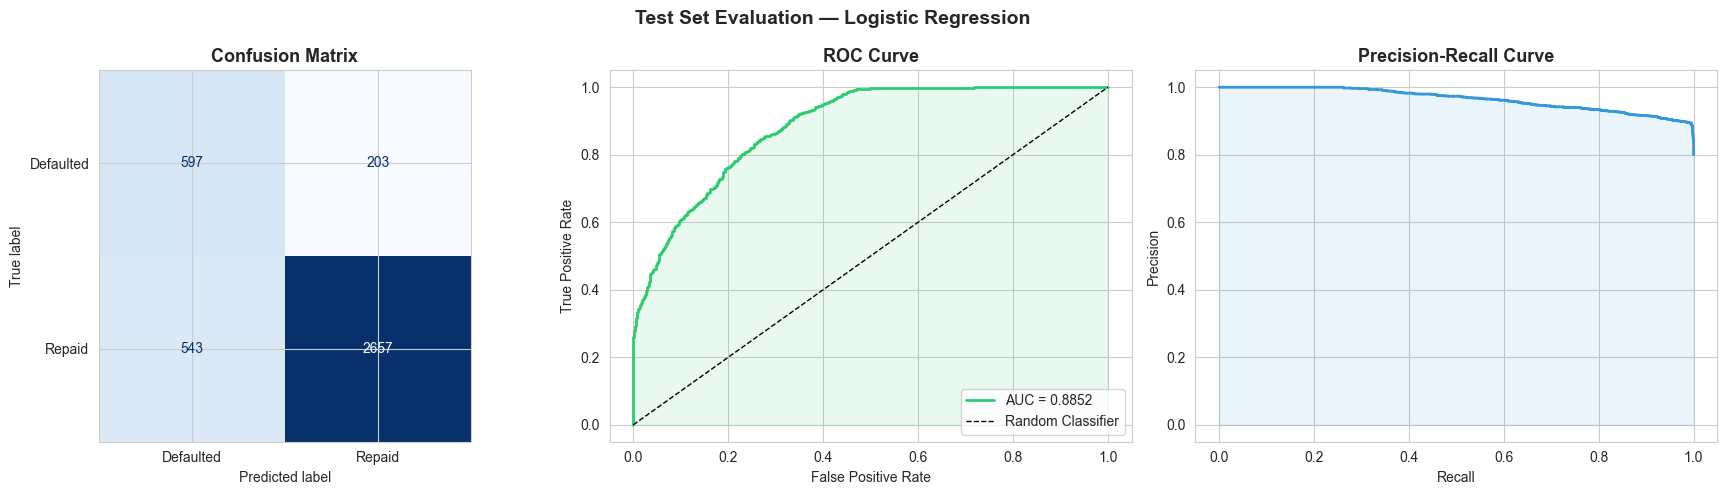

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 Confusion Matix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Defaulted','Repaid'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#2ecc71', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2ecc71')

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[2].plot(recall, precision, color='#3498db', lw=2)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[2].fill_between(recall, precision, alpha=0.1, color='#3498db')

plt.suptitle(f'Test Set Evaluation — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

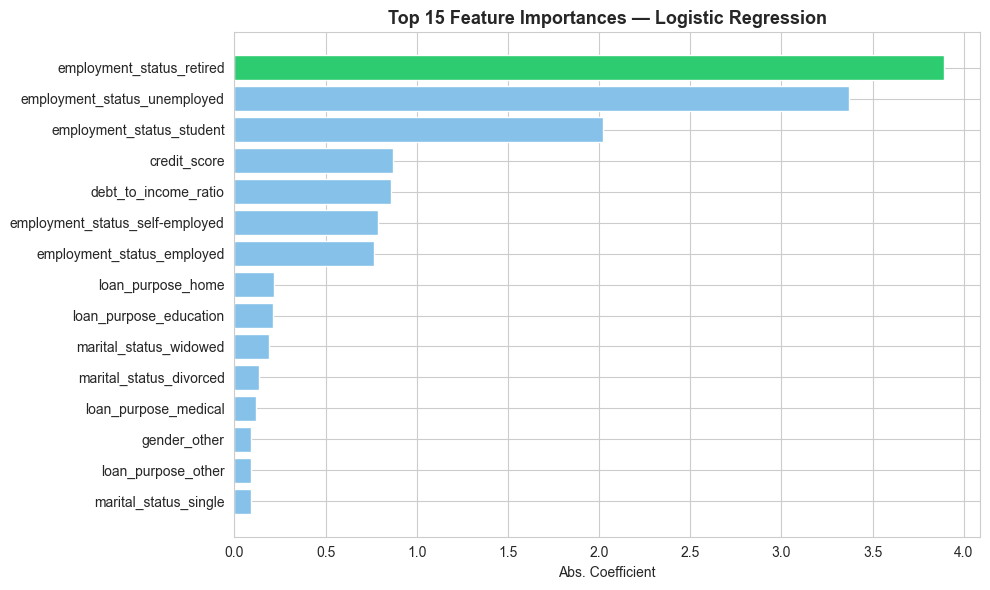

                        Feature  Importance
      employment_status_retired    3.894571
   employment_status_unemployed    3.371129
      employment_status_student    2.019385
                   credit_score    0.868397
           debt_to_income_ratio    0.860845
employment_status_self-employed    0.787763
     employment_status_employed    0.765744
              loan_purpose_home    0.214906
         loan_purpose_education    0.210666
         marital_status_widowed    0.190917
        marital_status_divorced    0.135102
           loan_purpose_medical    0.116592
                   gender_other    0.092346
             loan_purpose_other    0.090718
          marital_status_single    0.089063


In [88]:
classifier = tuned_pipeline.named_steps['classifier']
preprocessor_fit = tuned_pipeline.named_steps['preprocessor']

# Get feature names after one-hot encoding
cat_feature_names = preprocessor_fit.named_transformers_['cat'] \
    .named_steps['onehot'].get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feature_names

# Extract importances
if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    imp_label = 'Feature Importance'
elif hasattr(classifier, 'coef_'):
    importances = np.abs(classifier.coef_[0])
    imp_label = 'Abs. Coefficient'
else:
    raise ValueError("Model doesn't support feature importance extraction")

# Plot top 15 features
feat_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if i == 0 else '#85c1e9' for i in range(len(feat_df))]
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color=colors[::-1])
plt.xlabel(imp_label)
plt.title(f'Top 15 Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

## 9. Save Best Model

In [89]:
os.makedirs('../models', exist_ok=True)

model_path = '../models/loan_default_model.pkl'
joblib.dump(best_pipeline, model_path)

print(f'✅ Model saved to: {model_path}')
print(f'   Model type    : {best_model_name}')
print(f'   AUC (test)    : {auc:.4f}')
print()


✅ Model saved to: ../models/loan_default_model.pkl
   Model type    : Logistic Regression
   AUC (test)    : 0.8852

